In [101]:
import sys 
sys.path.append('..')
sys.path.append('../src')

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
from PIL import Image
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset
import os

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: mps


In [102]:
# center x and y bound. 


class Bin:
    def __init__(self, centre_x, bound_x , centre_y, bound_y):
        self.centre_x = centre_x
        self.centre_y = centre_y
        self.bound_x = bound_x
        self.bound_y = bound_y

waypoint_parameters = [Bin(0.2, 0.2, 0.0, 0.05), 
                       Bin(0.4, 0.3, 0.0, 0.3), 
                       Bin(0.6, 0.5, 0.0, 0.5), 
                       Bin(0.8, 0.5, 0.0, 1.0)]

class Bins:
    def __init__(self, waypoint_parameters, num_bins = 21):
        self.waypoint_parameters = waypoint_parameters

        self.y_bins = [self.symmetric_poly_bins(wp.centre_y, wp.bound_y, n=num_bins, power=2) for wp in waypoint_parameters]
        self.x_bins = [self.symmetric_poly_bins(wp.centre_x, wp.bound_x, n=num_bins, power=2) for wp in waypoint_parameters]
        self.num_bins = len(self.x_bins[0])
        print(self.num_bins)
        print(self.x_bins)
        print(self.y_bins)

    def symmetric_poly_bins(self, centre, bound, n, power=3):
        x = np.linspace(0, 1, n//2)
        curved = x ** power
        pos = (curved * bound)
        pos_p = pos[1:] + centre
        pos_n = -pos[::-1] + centre
        return np.concatenate([pos_n, pos_p])
    
    def get_closest_bin(self, x, y, waypoint_idx):
        x_bin_centers = self.x_bins[waypoint_idx]
        y_bin_centers = self.y_bins[waypoint_idx]
        x_idx = (np.abs(x_bin_centers - x)).argmin()
        y_idx = (np.abs(y_bin_centers - y)).argmin()
        return [x_idx, y_idx]

    def get_xy_from_bin(self, x_idx, y_idx, waypoint_idx):
        x_bin_centers = self.x_bins[waypoint_idx]
        y_bin_centers = self.y_bins[waypoint_idx]
        return [x_bin_centers[x_idx], y_bin_centers[y_idx]]
    

data_folder = 'house_fine_tune'
model_name = 'house_dist_fine_tune'

class ModelContextV3():
    def __init__(self, 
                 channels = 3,
                 width = 256,
                 height = 256,
                 mean = [0.485, 0.456, 0.406],
                 std=[0.225, 0.225, 0.225],
                 levels = [64, 128, 256],
                 hidden_dim = 512,
                 waypoint_num = 8,
                 data_type = torch.float32,
                 data_type_np = np.float32,
                 num_prev_observations = 4,
                 embedding_dim = 512,
                 attention_blocks = 2,
                 bin_type = torch.long,
                 discretisation = Bins(waypoint_parameters)
                ):
          self.mean = mean
          self.std = std
          self.waypoint_num = waypoint_num
          self.data_type = data_type
          self.data_type_np = data_type_np
          self.channels = channels
          self.width = width
          self.height = height
          self.device = torch.device('mps' if torch.mps.is_available() else 'cpu')
          self.levels = levels
          self.hidden_dim = hidden_dim
          self.num_prev_observations = num_prev_observations
          self.embedding_dim = embedding_dim
          self.attention_blocks = attention_blocks
          self.bin_type = bin_type
          self.discretisation = discretisation

          print('Using device:', self.device)

model_context = ModelContextV3(waypoint_num=4, num_prev_observations=0, levels=[64, 128, 256, 512, 1024], height=280, width=280, embedding_dim=256, hidden_dim=256, bin_type=torch.long)


19
[array([0.        , 0.04197531, 0.07901235, 0.11111111, 0.1382716 ,
       0.16049383, 0.17777778, 0.19012346, 0.19753086, 0.2       ,
       0.20246914, 0.20987654, 0.22222222, 0.23950617, 0.2617284 ,
       0.28888889, 0.32098765, 0.35802469, 0.4       ]), array([0.1       , 0.16296296, 0.21851852, 0.26666667, 0.30740741,
       0.34074074, 0.36666667, 0.38518519, 0.3962963 , 0.4       ,
       0.4037037 , 0.41481481, 0.43333333, 0.45925926, 0.49259259,
       0.53333333, 0.58148148, 0.63703704, 0.7       ]), array([0.1       , 0.20493827, 0.29753086, 0.37777778, 0.44567901,
       0.50123457, 0.54444444, 0.57530864, 0.59382716, 0.6       ,
       0.60617284, 0.62469136, 0.65555556, 0.69876543, 0.75432099,
       0.82222222, 0.90246914, 0.99506173, 1.1       ]), array([0.3       , 0.40493827, 0.49753086, 0.57777778, 0.64567901,
       0.70123457, 0.74444444, 0.77530864, 0.79382716, 0.8       ,
       0.80617284, 0.82469136, 0.85555556, 0.89876543, 0.95432099,
       1.02222222, 1.

In [15]:
def normalise_heading(yaw):
    while yaw > np.pi:
        yaw -= 2 * np.pi
    while yaw < -np.pi:
        yaw += 2 * np.pi
    return yaw

class TrajectorySample:
    def __init__(self, data_folder, model_context, transform=None, frame_skips=1, waypoint_skips=1):
        self.data_folder = data_folder
        self.transform = transform
        self.trajectory_data = pd.read_csv(f'{data_folder}/trajectory_data.csv')
        self.trajectory_data.drop(columns='speed', inplace=True)
        self.num_waypoints = model_context.waypoint_num
        self.data_type = model_context.data_type
        self.frame_skips = frame_skips
        self.waypoint_skips = waypoint_skips
        self.num_prev_observations = model_context.num_prev_observations
        self.model_context = model_context

    def orient_to_reference(self, current_waypoint, waypoints):
        ref_x = current_waypoint['x']
        ref_y = current_waypoint['y']
        ref_yaw = current_waypoint['yaw']

        h_sin = np.sin(-ref_yaw)
        h_cos = np.cos(-ref_yaw)

        ref_yaw = normalise_heading(ref_yaw)

        for i in range(len(waypoints)):
            dx = waypoints.at[i, 'x'] - ref_x
            dy = waypoints.at[i, 'y'] - ref_y

            # Rotate by -ref_yaw
            rotated_x = dx * h_cos - dy * h_sin
            rotated_y = dx * h_sin + dy * h_cos

            waypoints.at[i, 'x'] = rotated_x
            waypoints.at[i, 'y'] = rotated_y

            # orient yaw to heading =0. 
            waypoints.at[i, 'yaw'] -= ref_yaw
            waypoints.at[i, 'yaw'] = normalise_heading(waypoints.at[i, 'yaw'])


    def get_obs_waypoints(self, idx):
        if (idx < 0) or (idx >= len(self.trajectory_data)):
            raise IndexError("Index out of bounds")
        
        num_observations = []

        for obs_idx in range(idx - (self.num_prev_observations * self.frame_skips), idx + 1, self.frame_skips):
            obs_idx = max(0, obs_idx) ## clamp to 0, padding with first frame if needed
            o_t = Image.open(f'{self.data_folder}/frame_{obs_idx}.png').convert('RGB')
            if self.transform:
                o_t = self.transform(o_t).type(self.data_type).to(device)
            num_observations.append(o_t)

        num_observations.reverse()

        ## to match the tensorRT input 
        o_t = torch.cat(num_observations, dim=0)
        o_t = o_t.view(self.model_context.num_prev_observations + 1, 
                       self.model_context.channels, 
                       self.model_context.height, 
                       self.model_context.width)
        
        
        waypoints = None

        current_waypoint = self.trajectory_data.iloc[idx]
        end_index = idx + (self.num_waypoints * self.waypoint_skips) + 1

        indexes = list(range(idx + self.waypoint_skips, end_index, self.waypoint_skips))

        for waypoint_index, index in enumerate(indexes):
            if index >= len(self.trajectory_data):
                indexes[waypoint_index] = len(self.trajectory_data) - 1

        waypoints = self.trajectory_data.iloc[indexes]
        waypoints = waypoints.reset_index(drop=True)
        self.orient_to_reference(current_waypoint, waypoints)
        waypoints = waypoints[['x', 'y']]

        return o_t, waypoints
    

    def __getitem__(self, idx):
        o_t, waypoints = self.get_obs_waypoints(idx)
        waypoints = waypoints[['x', 'y']]

        waypoint_bins = []
        for i, (x, y) in enumerate(waypoints.values):
            xy = self.model_context.discretisation.get_closest_bin(x, y, i)
            # swap to (y, x) -> for modelV3 so x depends on y. 
            xy.reverse()
            waypoint_bins.append(xy)
        return o_t, torch.tensor(waypoint_bins, dtype=self.model_context.bin_type).to(device)

    def __len__(self):
        return len(self.trajectory_data) - (self.num_waypoints * self.waypoint_skips)

class BinnedWaypointDataset(Dataset):
    def __init__(self, data_folder, frame_skips, waypoint_skips, model_context, transform=None):
        self.w_num = model_context.waypoint_num
        self.transform = transform
        self.trajectories = []
        self.len = 0
        self.data_type = model_context.data_type
        self.mean = model_context.mean
        self.std = model_context.std
        self.frame_skips = frame_skips
        self.waypoint_skips = waypoint_skips
        self.model_context = model_context

        base_path = '/Users/tom/Development/carbot_ai_model/processed_trajectories'
        self.data_folder = f'{base_path}/{data_folder}'

        self.load_trajectories()

    def load_trajectories(self):
        for trajectory in os.listdir(self.data_folder):
            trajectory_path = f'{self.data_folder}/{trajectory}'
            sample = TrajectorySample(trajectory_path, 
                                    model_context=self.model_context, 
                                    transform=self.transform, 
                                    frame_skips=self.frame_skips, 
                                    waypoint_skips=self.waypoint_skips)
            self.trajectories.append(sample)
            self.len += len(sample)

    def map_index_to_trajectory(self, idx):
        cumulative_length = 0
        for traj_index, trajectory in enumerate(self.trajectories):
            traj_length = len(trajectory)
            if idx < cumulative_length + traj_length:
                sample_index = idx - cumulative_length
                return traj_index, sample_index
            cumulative_length += traj_length
        raise IndexError("Index out of bounds")
    
    def __getitem__(self, idx):
        traj_index, sample_index = self.map_index_to_trajectory(idx)
        return self.trajectories[traj_index][sample_index]
    
    def get_non_binned_waypoints(self, idx):
        traj_index, sample_index = self.map_index_to_trajectory(idx)
        o_t, waypoints = self.trajectories[traj_index].get_obs_waypoints(sample_index)
        return o_t, waypoints
    
    def __len__(self):
        return self.len
    
    def denormalize_image(self, tensor):
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
        return tensor
    
    def view_sample(self, idx, num_prev_observations=0):
        o_t, binned_waypoints = self.__getitem__(idx)
        _, waypoints = self.get_non_binned_waypoints(idx)

        if num_prev_observations > self.model_context.num_prev_observations:
            num_prev_observations = self.model_context.num_prev_observations

        o_t = o_t.to('cpu')[0, :, :, :]
        o_t = self.denormalize_image(o_t)
        o_t = o_t.permute(1, 2, 0).numpy()

        fig, ax = plt.subplots(1, 2, figsize=(12, 6))
        ax[0].imshow(o_t)
        ax[0].set_title(f'Observation Image, Sample Index: {idx}, Previous Observations: {num_prev_observations}')
        ax[0].axis('off')
        ax[1].set_title('Waypoints in Robot-Centric Frame')


        binned_waypoints = binned_waypoints.to('cpu').numpy()
    
        xy_from_bins = [self.model_context.discretisation.get_xy_from_bin(binned_waypoints[i][1], binned_waypoints[i][0], i) for i in range(len(binned_waypoints))]
        ## note that x and y are swapped.
        x_dis = [xy[0] for xy in xy_from_bins]
        y_dis = [xy[1] for xy in xy_from_bins]
        y_dis = [-y for y in y_dis]

        ax[1].plot(y_dis, x_dis, marker='o', label='Binned Waypoints')
        
        x = waypoints[['x']].to_numpy()
        y = waypoints[['y']].to_numpy()

        y = -y

        max_y = max(abs(y)) + 0.5
        max_x = self.model_context.discretisation.waypoint_parameters[-1].centre_x + self.model_context.discretisation.waypoint_parameters[-1].bound_x

        ax[1].plot(y, x, marker='o', label='Actual Waypoints')
        ax[1].set_xlim(-max_y, max_y)
        ax[1].set_ylim(0, max_x)
        ax[1].set_aspect('equal', adjustable='box')
        ax[1].legend()
        plt.show()

def plot_waypoints(waypoints):
    xy = waypoints[:, :2]
    x = xy[:, 0].cpu().numpy()
    y = xy[:, 1].cpu().numpy()

    # Axis scale
    max_value = max(max(abs(x)), max(abs(y))) + 0.5

    plt.figure(figsize=(6, 6))
    plt.plot(x, y, marker='o')

    # Label points 1–8
    for i in range(xy.shape[0]):
        plt.text(x[i], y[i], str(i + 1), fontsize=12, ha='right', va='bottom')

    # Formatting
    plt.xlim(-max_value, max_value)
    plt.ylim(-max_value, max_value)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.title('Waypoints in Robot-Centric Frame')
    plt.grid()
    plt.show()

In [16]:
transform = transforms.Compose([
    transforms.Resize((model_context.height, model_context.width)),
    transforms.ToTensor(),
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2.0)),
    transforms.ColorJitter(brightness=0.4, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.Normalize(mean=model_context.mean, std=model_context.std)])

## 5fps so a frame every second as context.
frame_skips = 5
waypoint_skips = 2
dataset = BinnedWaypointDataset(data_folder=data_folder, frame_skips = frame_skips, waypoint_skips=waypoint_skips, model_context=model_context, transform=transform)

In [17]:
o_t, ys = dataset[10]
print(ys.shape)
print(o_t.shape)

## take [[y, x], [y, x], ...] -> [y, x, y, x, ...]
print(ys.reshape(-1).shape)

torch.Size([4, 2])
torch.Size([1, 3, 280, 280])
torch.Size([8])


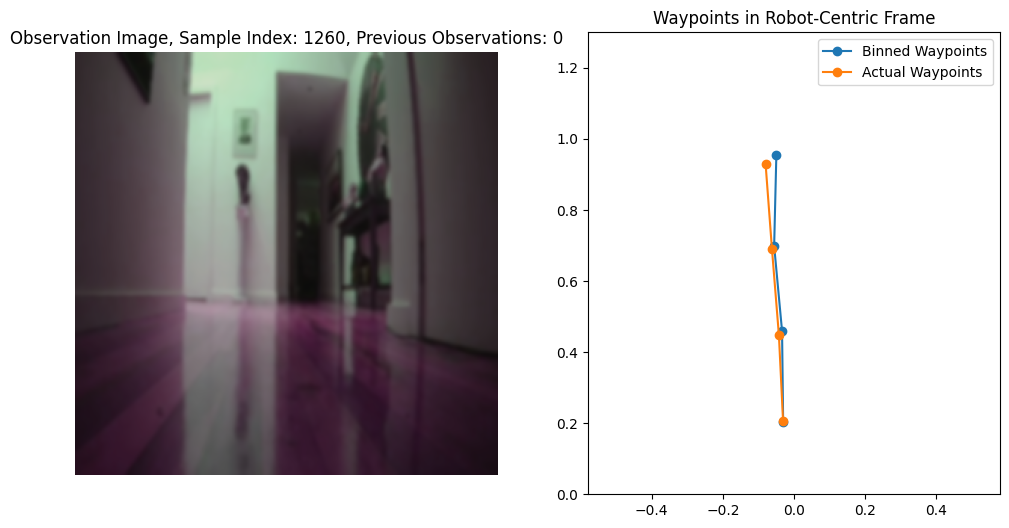

In [18]:
sample_idx = np.random.randint(0, len(dataset))
dataset.view_sample(sample_idx, num_prev_observations=0)

In [19]:
from model_v2 import Encoder 
import torch.nn as nn

class DiscretisedActionHead(nn.Module):
    def __init__(self, model_context, embed_dim: int, waypoint_num: int, dropout=0.2):
        super().__init__()

        self.num_bins = model_context.discretisation.num_bins
        # we guess y_0 first then x_0 -> y_1, ... 
        self.target_cols = (waypoint_num * 2 - 1) * self.num_bins

        self.waypoint_num = waypoint_num
        self.dropout = dropout
        self.waypoint_encoder = nn.Sequential(
            nn.Linear(self.target_cols, embed_dim),
            nn.Mish(),
            nn.Dropout(p=dropout),
            nn.Linear(embed_dim, embed_dim))

        # Action decoder computes the raw logits for each x, y with the same layer. 
        self.action_decoder = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.Mish(),
            nn.Dropout(p=dropout),
            nn.Linear(embed_dim * 4, embed_dim), 
            nn.Mish(), 
            nn.Dropout(p=dropout),
            nn.Linear(embed_dim, embed_dim // 2),
            nn.Mish(),
            nn.Dropout(p=dropout),
            nn.Linear(embed_dim // 2, self.num_bins))

    def forward(self, x):
        B, D = x.shape
        waypoint_xy_logits = []

        # Auto-regressive waypoint prediction
        for i in range(self.waypoint_num * 2):
            if i == 0:
                logits = self.forward_(x)
                waypoint_xy_logits.append(logits)
            else:
                ## cat [[B, num_bins], [B, num_bins], ...] -> [B, i * num_bins]
                prev_waypoint_logits = torch.cat(waypoint_xy_logits, dim=1)  # Concatenate previous waypoints
                padded = prev_waypoint_logits.new_zeros(B, self.target_cols)
                padded[:, :prev_waypoint_logits.shape[1]] = prev_waypoint_logits
                prev_waypoint_logits = padded
                raw_logits = self.forward_(x, prev_waypoint_logits)
                waypoint_xy_logits.append(raw_logits)

        # stack here stacks the [[B, num_bins], [B, num_bins], ...] -> [B, waypoint_num*2, num_bins]
        # i.e create a new dim at dim=1.
        logits = torch.stack(waypoint_xy_logits, dim=1)
        return logits

    # outputs a (B, num_bins) tensor
    def forward_(self, x, prev_waypoints = None):
        out = None
        if prev_waypoints is not None:
            prev_action_embed = self.waypoint_encoder(prev_waypoints)
            out = x + prev_action_embed
        out = self.action_decoder(out if out is not None else x)
        return out
    

action_head = DiscretisedActionHead(model_context, embed_dim=128, waypoint_num=4, dropout=0.2).to(device)

dummy_input = torch.randn(2, 128).to(device)
dummy_output = action_head(dummy_input)
print(dummy_output.shape)  # Expected output shape: (2, waypoint_num * 2
print(dummy_output[0, 0, :])

torch.Size([2, 8, 19])
tensor([-0.0761, -0.1394,  0.0200, -0.0201, -0.1254,  0.0146,  0.0395, -0.0144,
         0.0158, -0.0645, -0.0747,  0.0492,  0.0218, -0.1675,  0.0662,  0.0117,
        -0.0619, -0.0888, -0.1438], device='mps:0', grad_fn=<SelectBackward0>)


In [20]:
class ModelV3(nn.Module):
    def __init__(self, model_context):
        super().__init__()
        self.encoder = Encoder(model_context)
        self.action_head = DiscretisedActionHead(model_context, embed_dim=model_context.embedding_dim, waypoint_num=model_context.waypoint_num, dropout=0.2)

    def forward(self, x):
        x = x.squeeze(1)
        x = self.encoder(x)
        out = self.action_head(x)
        return out
    
model = ModelV3(model_context).to(device)
with torch.no_grad():
    dummy_input = torch.randn(2, 1, 3, model_context.height, model_context.width).to(device)
    dummy_output = model(dummy_input)
print(dummy_output.shape)  # Expected output shape: (2, waypoint_num * 2

torch.Size([2, 8, 19])


In [21]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

batch_size = 32
train_split = 0.90

train_idx, val_idx = train_test_split(list(range(len(dataset))), train_size=train_split, random_state=42)

  # Create data loaders
train_sampler = torch.utils.data.SubsetRandomSampler(train_idx)
val_sampler = torch.utils.data.SubsetRandomSampler(val_idx)

train_loader = DataLoader(dataset, batch_size=batch_size,
                            sampler=train_sampler, num_workers=0)
val_loader = DataLoader(dataset, batch_size=batch_size, 
                        sampler=val_sampler, num_workers=0)

In [22]:
## Setup optimizer and loss function
train_iters = 10
learning_rate = 2e-4
warmup_steps = 2000

def warmup_lr(step):
    return min(step, warmup_steps) / warmup_steps


optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=learning_rate)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, warmup_lr)
criterion = nn.MSELoss()

dummy_input = torch.randn(2, model_context.num_prev_observations + 1, model_context.channels, model_context.height, model_context.width).to(model_context.device)
with torch.no_grad():
    dummy_output = model(dummy_input)
print("Dummy output shape:", dummy_output.shape)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Dummy output shape: torch.Size([2, 8, 19])
Total parameters: 13,468,563


In [23]:
import tqdm as tqdm

def train_model(model, train_loader, val_loader, optimizer, scheduler, train_iters, save_model_path, model_context):
    avg_losses = []
    avg_val_losses = []
    av_accuracies = []
    av_val_accuracies = []

    # see https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html 

    # Input should (N, C) and target (N) where each value is 0 <= targets[i] <= C-1
    criterion = nn.CrossEntropyLoss()

    device = model_context.device
    data_type = model_context.data_type
    min_val_loss = float('inf')

    weights = None 


    for epoch in range(train_iters):
        model.train()
        running_loss = 0.0
        running_accuracy = 0.0
        pbar = tqdm.tqdm(train_loader, desc=f'Epoch {epoch+1}/{train_iters}', unit='batch')

        for i, (inputs, targets) in enumerate(pbar):
            inputs = inputs.to(device).to(data_type)
            targets = targets.to(device).to(data_type)

            # From (B, waypoints, 2) -> (B * waypoints*2)
            targets = targets.view(-1).long()

            optimizer.zero_grad()
            outputs = model(inputs)

            # (B, waypoints*2, num_bins) -> (B * waypoints*2, num_bins)
            outputs = outputs.view(-1, model_context.discretisation.num_bins)

            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            scheduler.step()

            pred_bins = torch.argmax(outputs, dim=1)
            correct = (pred_bins == targets).float().mean()
            running_loss += loss.item()
            running_accuracy += correct.item()

        avg_loss = running_loss / len(train_loader)
        avg_accuracy = running_accuracy / len(train_loader)
        print(f'Epoch [{epoch+1}/{train_iters}], Loss: {avg_loss:.4f}, Accuracy: {avg_accuracy:.4f}')

        # Validation step
        model.eval()
        val_loss = 0.0
        running_val_accuracy = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs = inputs.to(device).to(data_type)
                targets = targets.to(device).to(data_type)

                # From (B, waypoints, 2) -> (B * waypoints*2)
                targets = targets.view(-1).long()

                outputs = model(inputs)

                # (B, waypoints*2, num_bins) -> (B * waypoints*2, num_bins)
                outputs = outputs.view(-1, model_context.discretisation.num_bins)

                loss = criterion(outputs, targets)
                val_loss += loss.item()

                pred_bins = torch.argmax(outputs, dim=1)
                correct = (pred_bins == targets).float().mean()
                running_val_accuracy += correct.item()

        avg_val_loss = val_loss / len(val_loader)
        avg_val_accuracy = running_val_accuracy / len(val_loader)
        print(f'Validation Loss: {avg_val_loss:.4f}, Accuracy: {avg_val_accuracy:.4f}')

        base_path = '/Users/tom/Development/carbot_ai_model/models'

        if (avg_val_loss < min_val_loss):
            min_val_loss = avg_val_loss
            torch.save(model.state_dict(), f'{base_path}/{save_model_path}/best_model.pth')
            print(f'Saved best model with validation loss: {min_val_loss:.4f}')

        avg_losses.append(avg_loss)
        avg_val_losses.append(avg_val_loss)
        av_accuracies.append(avg_accuracy)
        av_val_accuracies.append(avg_val_accuracy)

    return avg_losses, avg_val_losses, av_accuracies, av_val_accuracies

def view_val_train_loss(avg_losses, avg_val_losses):
    plt.plot(avg_losses, label='Training Loss')
    plt.plot(avg_val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss over Epochs')
    plt.legend()
    plt.grid()
    plt.show()

In [12]:
train_loss, val_loss, train_accuracies, val_accuracies = train_model(model, 
                                                                     train_loader, 
                                                                     val_loader, 
                                                                     optimizer, 
                                                                     scheduler, 
                                                                     train_iters, 
                                                                     save_model_path=model_name, 
                                                                     model_context=model_context)

Epoch 1/10:   2%|▏         | 1/66 [00:03<04:08,  3.82s/batch]


KeyboardInterrupt: 

In [24]:
prev_checkpoint = 'house_dist'

best_model = ModelV3(model_context=model_context).to(model_context.device)
best_model.load_state_dict(torch.load(f'../models/{prev_checkpoint}/best_model.pth'))
best_model.train()

train_loss, val_loss, train_accuracies, val_accuracies = train_model(best_model, 
                                                                     train_loader, 
                                                                     val_loader, 
                                                                     optimizer, 
                                                                     scheduler, 
                                                                     train_iters, 
                                                                     save_model_path=model_name, 
                                                                     model_context=model_context)



Epoch 1/10: 100%|██████████| 66/66 [02:01<00:00,  1.84s/batch]


Epoch [1/10], Loss: 1.5603, Accuracy: 0.4810
Validation Loss: 1.4905, Accuracy: 0.4753
Saved best model with validation loss: 1.4905


Epoch 2/10: 100%|██████████| 66/66 [02:05<00:00,  1.90s/batch]


Epoch [2/10], Loss: 1.5678, Accuracy: 0.4805
Validation Loss: 1.4954, Accuracy: 0.4818


Epoch 3/10: 100%|██████████| 66/66 [02:28<00:00,  2.25s/batch]


...

Epoch [8/10], Loss: 1.5672, Accuracy: 0.4818
Validation Loss: 1.4783, Accuracy: 0.4827


Epoch 9/10: 100%|██████████| 66/66 [02:51<00:00,  2.60s/batch]


Epoch [9/10], Loss: 1.5618, Accuracy: 0.4829
Validation Loss: 1.4689, Accuracy: 0.4858


Epoch 10/10: 100%|██████████| 66/66 [02:45<00:00,  2.51s/batch]


Epoch [10/10], Loss: 1.5717, Accuracy: 0.4802
Validation Loss: 1.5477, Accuracy: 0.4728


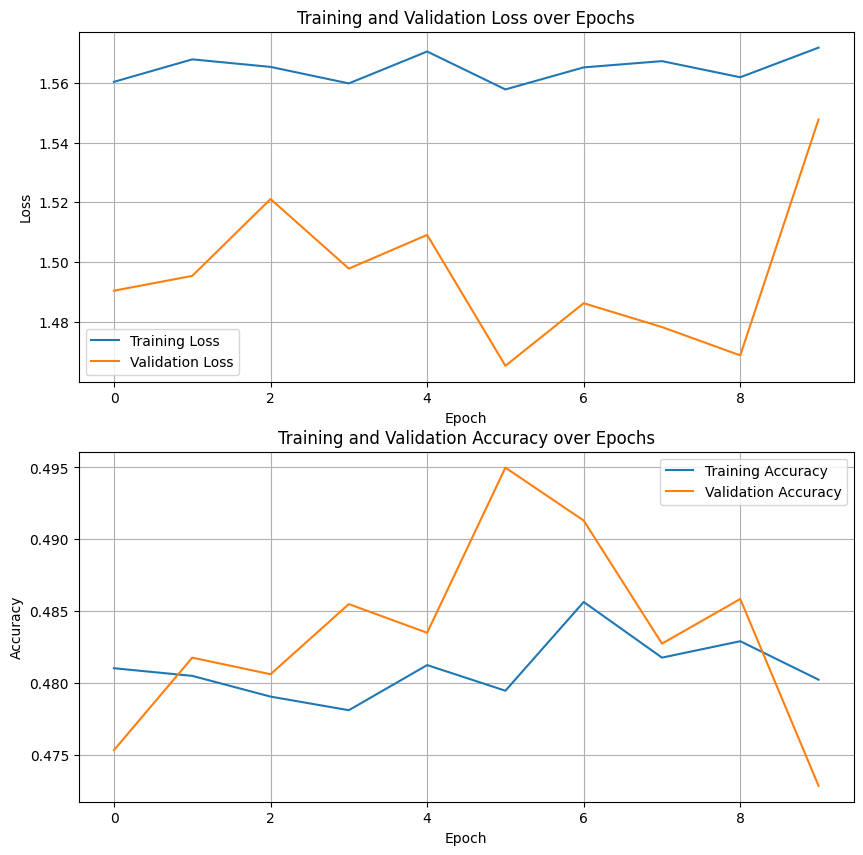

In [25]:
def view_val_train_loss(avg_losses, avg_val_losses, avg_accuracies, avg_val_accuracies):
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    ax[0].plot(avg_losses, label='Training Loss')
    ax[0].plot(avg_val_losses, label='Validation Loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].set_title('Training and Validation Loss over Epochs')
    ax[0].legend()
    ax[0].grid()

    ax[1].plot(avg_accuracies, label='Training Accuracy')
    ax[1].plot(avg_val_accuracies, label='Validation Accuracy')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy')
    ax[1].set_title('Training and Validation Accuracy over Epochs')
    ax[1].legend()
    ax[1].grid()
    plt.show()

view_val_train_loss(train_loss, val_loss, train_accuracies, val_accuracies)


In [26]:
best_model = ModelV3(model_context=model_context).to(model_context.device)
best_model.load_state_dict(torch.load(f'../models/{model_name}/best_model.pth'))

<All keys matched successfully>

In [28]:
def predict_waypoints(o_t, model, model_context):
    model.eval()
    print(o_t.shape)
    with torch.no_grad():
        logits = model(o_t).squeeze(0)  # Remove batch dimension

    predicts = torch.argmax(logits, dim=1).cpu().numpy()
    return predicts

def view_evaluation_sample_dist(idx, model, dataloader, num_prev_observations=0):
        o_t, binned_waypoints = dataloader[idx]
        _, waypoints = dataloader.get_non_binned_waypoints(idx)

        predicts = predict_waypoints(o_t, model, dataloader.model_context)

        if num_prev_observations > dataloader.model_context.num_prev_observations:
            num_prev_observations = dataloader.model_context.num_prev_observations

        o_t = o_t.to('cpu')[0, :, :, :]
        o_t = dataloader.denormalize_image(o_t)
        o_t = o_t.permute(1, 2, 0).numpy()

        fig, ax = plt.subplots(1, 2, figsize=(12, 6))
        ax[0].imshow(o_t)
        ax[0].set_title(f'Observation Image, Sample Index: {idx}, Previous Observations: {num_prev_observations}')
        ax[0].axis('off')
        ax[1].set_title('Waypoints in Robot-Centric Frame')


        # (num_waypoints * 2,)
        xy_from_bins_pred = [dataloader.model_context.discretisation.get_xy_from_bin(predicts[i * 2 + 1], predicts[i * 2], i) for i in range(len(predicts) // 2)]
        x_dis_pred = [xy[0] for xy in xy_from_bins_pred]
        y_dis_pred = [xy[1] for xy in xy_from_bins_pred]
        y_dis_pred = [-y for y in y_dis_pred]
        ax[1].plot(y_dis_pred, x_dis_pred, marker='o', label='Predicted Waypoints')


        binned_waypoints = binned_waypoints.to('cpu').numpy()
    
        xy_from_bins = [dataloader.model_context.discretisation.get_xy_from_bin(binned_waypoints[i][1], binned_waypoints[i][0], i) for i in range(len(binned_waypoints))]
        ## note that x and y are swapped.
        x_dis = [xy[0] for xy in xy_from_bins]
        y_dis = [xy[1] for xy in xy_from_bins]
        y_dis = [-y for y in y_dis]

        ax[1].plot(y_dis, x_dis, marker='o', label='Binned Waypoints')
        
        x = waypoints[['x']].to_numpy()
        y = waypoints[['y']].to_numpy()

        y = -y

        max_y = max(abs(y)) + 0.5
        max_x = dataloader.model_context.discretisation.waypoint_parameters[-1].centre_x + dataloader.model_context.discretisation.waypoint_parameters[-1].bound_x

        ax[1].plot(y, x, marker='o', label='Actual Waypoints')
        ax[1].set_xlim(-max_y, max_y)
        ax[1].set_ylim(0, max_x)
        ax[1].set_aspect('equal', adjustable='box')
        ax[1].legend()
        plt.show()

torch.Size([1, 3, 280, 280])


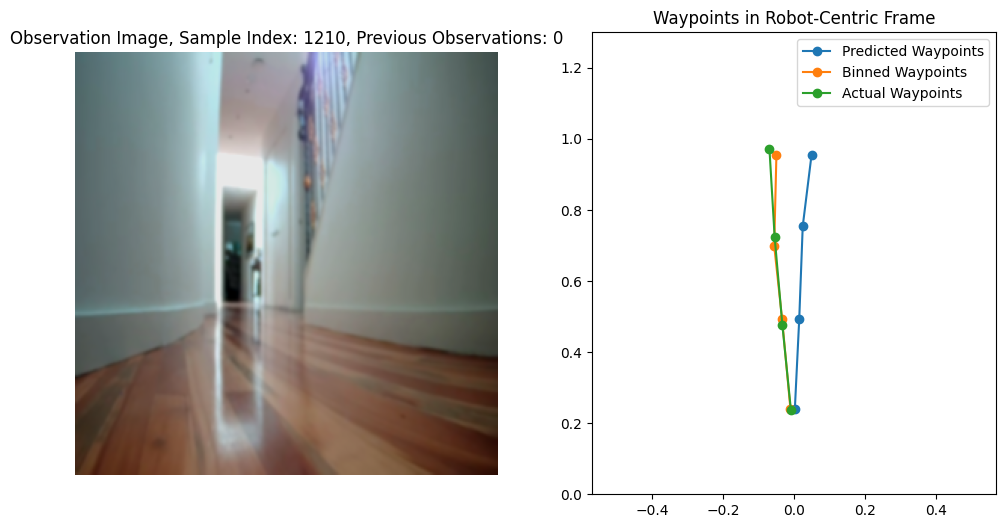

In [99]:
sample_idx = np.random.randint(0, len(dataset))
view_evaluation_sample_dist(sample_idx, best_model, dataset)

In [100]:
from export_model import export_model_to_onnx_v2

export_model_to_onnx_v2(best_model, model_name, model_name, model_context)

ONNX model is valid.


ModelProto(ir_version=8, opset_import={'': 18}, producer_name='pytorch', producer_version='2.9.1', graph=GraphProto('main_graph', input=<1 inputs>, output=<1 outputs>, initializer=<44 initializers>, node=<452 nodes>))

In [ ]:
array = np.fromfile(f'../output/input_tensor_0.bin', dtype=model_context.data_type_np)
input_tensor_0 = array.reshape(1, 3, model_context.height, model_context.width)

tensor = torch.tensor(input_tensor_0).to(device)

output = best_model(tensor[None, :, :, :, :]).squeeze(0)
print(output.shape)  # Expected output shape: (1, waypoint_num * 2,

output = torch.argmax(output, dim=1).cpu().numpy()
print(output.shape)  # Expected output shape: (waypoint_num * 2,)

xy_from_bins = [model_context.discretisation.get_xy_from_bin(output[2 * i + 1], output[2 * i], i) for i in range(len(output) // 2)]
for i, xy in enumerate(xy_from_bins):
    print(f'Waypoint {i+1}: x = {xy[0]:.4f}, y = {xy[1]:.4f}')

In [ ]:
from rollout_reply import ReplayModelRollout

base_arr = '/Users/tom/Development/carbot_ai_model/model_rollouts'
rollout = ReplayModelRollout(data_dir=f'{base_arr}/1763587523', model_context=model_context)
rollout.see_observations_with_slider()